<a href="https://colab.research.google.com/github/Bela1810/company-data-analysis/blob/main/company_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👩🏻‍🎓 **Integrantes**
- Juan Camilo Manjarres
- Daniel Ospina
- Isabella Montoya Castellanos


#**Actividad Evaluativa**

##**Contexto de la base**
Esta base corresponde a empleados de una empresa e incluye variables sociodemográficas, condiciones laborales, compensación, desempeño y la variable objetivo Attrition (si el empleado dejó la empresa: Yes/No).

El objetivo del ejercicio es aplicar un flujo completo de análisis exploratorio, detectar problemas típicos de calidad (faltantes, tipos erróneos, valores extremos, inconsistencias), documentar las decisiones y obtener un conjunto de variables “listas” para análisis.


##**Instrucciones**

###**Parte A.  Diccionario de variables**
1. Construir una tabla “diccionario” con todas las variables y estas columnas:
  -	Nombre original
  -	Descripción (qué mide)
  -	Tipo de variable (cualitativa nominal/ordinal; cuantitativa discreta/continua; binaria)

**Producto A1 (entregable):** tabla diccionario completa.

---

###**Parte B.  Seleccione 5 variables para limpieza profunda**
Para cada una de las 5 variables:

1. Estandarización de tipo
    -	Convertir a numérico/categórico según corresponda.

2.	Tratamiento de valores inválidos

  -	Definir reglas: qué se considera inválido y qué se hace (NA, recodificación, eliminación).

3.	Faltantes
  -	Elegir e implementar una estrategia para el tratamiento de los datos faltantes según el tipo de variable.
  -	Reportar: antes vs después (% NA).
4.	Outliers:
  -	Detectar outliers y decidir el tratamiento a utilizar para su corrección.

5.	Registro de cambios

  -	Producto B1: bitácora detallada (ver formato abajo).
  -	Producto B2: mini-tabla “antes/después” para cada variable (tipo, NA%, outliers detectados, decisión tomada).

---

###**Parte C. Análisis exploratorio con variables limpias**

Con las 5 variables ya limpias, calcule e interprete:

-	Medidas de tendencia central y dispersión (numéricas)
-	Tablas de frecuencia
-	Datos cualitativos
-	Datos cuantitativos (Clases, frecuencia absoluta, relativa, acumulada absoluta, acumulada relativa)
-	Gráficos
-	Datos cualitativos (Gráfico de barras, gráfico de tortas)
-	Datos cuantitativos (Gráfico de cajas, histograma, polígono de frecuencia, ojiva)
-	Relaciones
-	Correlación entre numéricas (Pearson/Spearman según distribución y justificación)

**Producto C1:** sección de resultados con tablas y gráficos.

**Producto C2:** interpretación escrita (mínimo 10–15 líneas): hallazgos clave.

---

##BITÁCORA

Formato obligatorio de bitácora (para el notebook o informe)

Debe quedar como “registro de laboratorio”, con esta estructura:

1.	Objetivo del análisis
2.	Descripción de la base (Producto A1)
3.	Auditoría global de calidad de 5 variables
4.	Limpieza variable por variable

  -	Problema detectado
  -	Evidencia (conteos/ejemplos)
  -	Regla aplicada
  -	Resultado (antes/después) Producto B2
5.	AED final con variables limpias
6.	Conclusiones y limitaciones
7.	Anexo opcional: código y notebook


###Criterios de evaluación (rúbrica rápida)

- Diccionario completo y correcto (20%)
- Limpieza profunda justificada y reproducible (30%)
- Análisis descriptivo y visualizaciones (30%)
- Interpretación y bitácora (20%)


#**Desarrollo**

In [ ]:
#Librerias

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis, norm


In [ ]:
#Mount and connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/UdeM/EstadisticaIA/Actividad1.csv' #Ruta Manja

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/Actividad1.csv' #Ruta Daniel

In [ ]:
file_path = '/content/Actividad1.csv'

In [ ]:
df = pd.read_csv(file_path)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1482 non-null   object 
 1   Attrition                 1355 non-null   object 
 2   BusinessTravel            1427 non-null   object 
 3   DailyRate                 1499 non-null   int64  
 4   Department                1344 non-null   object 
 5   DistanceFromHome          1390 non-null   object 
 6   Education                 1477 non-null   object 
 7   EducationField            1438 non-null   object 
 8   EmployeeCount             1499 non-null   object 
 9   EmployeeNumber            1499 non-null   int64  
 10  EnvironmentSatisfaction   1499 non-null   int64  
 11  Gender                    1438 non-null   object 
 12  HourlyRate                1499 non-null   int64  
 13  JobInvolvement            1499 non-null   int64  
 14  JobLevel

In [ ]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sin dato,1.0%,2,Sin dato,1,1,...,NaN,80.0,0,8.0,0,1,6,4,0.0,5
1,NaN,No,Travel_Frequently,279,Research & Development,8.0,1,Life Sciences,1,2,...,4.0,80.0,1,NaN,3,3,10,7,1.0,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2.0,165.52537747275642,Other,1,4,...,2.0,80.0,0,7.0,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3.0,4,Life Sciences,1,5,...,3.0,80.0,0,8.0,3,3,8,7,3.0,missing
4,27,No,Travel_Rarely,591,Research & Development,2.0,1,Medical,1,7,...,4.0,80.0,1,6.0,20220335,3,2,2,2.0,2


#**PRODUCTO B1 - BITACORA**

**OBJETIVO DEL ANALISIS**

Aplicar un proceso integral de análisis exploratorio de datos (EDA) sobre una base de empleados, con el propósito de evaluar la calidad de la información e identificar problemas comunes como valores faltantes, inconsistencias, tipos de datos inadecuados y valores atípicos. A partir de este diagnóstico, se busca implementar procesos de limpieza, transformación y estandarización de variables que garanticen la coherencia y confiabilidad de los datos. Finalmente, se pretende obtener un conjunto de variables depuradas que permitan realizar análisis descriptivos e interpretar de manera adecuada los comportamientos presentes en la información.

# ⇨ **Parte A**



##⇨  **PRODUCTO A1 DESCRIPCIÓN DE LA BASE - Tabla diccionario de variables**

| # | Variable | Tipo de variable | Descripción |
|---|----------|-----------------|-------------|
| 0 | Age | Numérica discreta | Edad del empleado en años |
| 1 | Attrition | Categórica nominal | Indica si el empleado abandonó la empresa |
| 2 | BusinessTravel | Categórica nominal | Frecuencia de viajes de negocios del empleado |
| 3 | DailyRate | Numérica discreta | Tarifa diaria de pago del empleado |
| 4 | Department | Categórica nominal | Departamento en el que trabaja el empleado |
| 5 | DistanceFromHome | Numérica discreta | Distancia en km desde el hogar al lugar de trabajo |
| 6 | Education | Categórica ordinal | Nivel educativo alcanzado por el empleado |
| 7 | EducationField | Categórica nominal | Campo o área de estudio del empleado |
| 8 | EmployeeCount | Numérica discreta | Conteo de empleados |
| 9 | EmployeeNumber | Numérica discreta | Identificador numérico único del empleado |
| 10 | EnvironmentSatisfaction | Categórica ordinal | Nivel de satisfacción con el ambiente laboral  |
| 11 | Gender | Categórica nominal | Género del empleado  |
| 12 | HourlyRate | Numérica discreta | Tarifa de pago por hora del empleado |
| 13 | JobInvolvement | Categórica ordinal | Nivel de implicación del empleado en su trabajo  |
| 14 | JobLevel | Categórica ordinal | Nivel jerárquico del puesto del empleado  |
| 15 | JobRole | Categórica nominal | Rol o cargo específico que desempeña el empleado |
| 16 | JobSatisfaction | Categórica ordinal | Nivel de satisfacción del empleado con su trabajo  |
| 17 | MaritalStatus | Categórica nominal | Estado civil del empleado  |
| 18 | MonthlyIncome | Numérica continua | Ingreso mensual del empleado en dólares |
| 19 | MonthlyRate | Numérica discreta | Tarifa mensual asignada al empleado |
| 20 | NumCompaniesWorked | Numérica discreta | Número de empresas en las que ha trabajado anteriormente |
| 21 | Over18 | Categórica nominal | Indica si el empleado es mayor de 18 años  |
| 22 | OverTime | Categórica nominal | Indica si el empleado realiza horas extra  |
| 23 | PercentSalaryHike | Numérica discreta | Porcentaje de aumento salarial recibido en el último año |
| 24 | PerformanceRating | Categórica ordinal | Calificación del desempeño del empleado  |
| 25 | RelationshipSatisfaction | Categórica ordinal | Nivel de satisfacción con las relaciones laborales  |
| 26 | StandardHours | Numérica continua | Horas estándar de trabajo establecidas  |
| 27 | StockOptionLevel | Categórica ordinal | Nivel de opciones sobre acciones otorgadas al empleado  |
| 28 | TotalWorkingYears | Numérica continua | Total de años de experiencia laboral del empleado |
| 29 | TrainingTimesLastYear | Numérica discreta | Número de capacitaciones recibidas durante el último año |
| 30 | WorkLifeBalance | Categórica ordinal | Nivel de equilibrio entre vida personal y laboral  |
| 31 | YearsAtCompany | Numérica discreta | Número de años que el empleado lleva en la empresa |
| 32 | YearsInCurrentRole | Numérica discreta | Número de años en el puesto actual dentro de la empresa |
| 33 | YearsSinceLastPromotion | Numérica discreta | Años transcurridos desde el último ascenso del empleado |
| 34 | YearsWithCurrManager | Numérica discreta | Número de años trabajando con el mismo manager |

# ⇨ **Parte B**
Variables seleccionadas:







| # | Variable | Tipo de variable | Descripción |
|---|----------|-----------------|-------------|
| 1 |PerformanceRating	|Categórica ordinal|	Calificación del desempeño del empleado|
| 2 | JobSatisfaction	| Categórica ordinal | Nivel de satisfacción del empleado con su trabajo |
| 3 | Department |	Categórica nominal |	Departamento en el que trabaja el empleado|
| 4 | Age |	 Numérica discreta |	Edad del empleado en años |
| 5 | DistanceFromHome | Numérica discreta |	Distancia en km desde el hogar al lugar de trabajo |
| 6 | Attrition	| Categórica nominal | Indica si el empleado abandonó la empresa




In [ ]:
df2 = df[["Age", "PerformanceRating", "JobSatisfaction", "Department", "Attrition", "DistanceFromHome"]]

In [ ]:
df2.head()

,Age,PerformanceRating,JobSatisfaction,Department,Attrition,DistanceFromHome
0,41,3,4,Sin dato,Yes,1.0%
1,NaN,4,2,Research & Development,No,8.0
2,37,3,3,Research & Development,Yes,2.0
3,33,3,3,Research & Development,No,3.0
4,27,3,2,Research & Development,No,2.0


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1482 non-null   object
 1   PerformanceRating  1486 non-null   object
 2   JobSatisfaction    1499 non-null   int64 
 3   Department         1344 non-null   object
 4   Attrition          1355 non-null   object
 5   DistanceFromHome   1390 non-null   object
dtypes: int64(1), object(5)
memory usage: 70.4+ KB


## ▻  **Auditoria Global de Calidad de las Variables / Estandarización de Tipo - Conversión de variables**

A partir de una revisión inicial de las variables seleccionadas, se identificaron distintos problemas de calidad de datos que podrían afectar su análisis. En primer lugar, se observó la presencia de valores inconsistentes o no válidos, como registros con texto, símbolos o formatos incorrectos en variables que deberían seguir una estructura definida.

Adicionalmente, se evidenciaron valores faltantes, tanto explícitos como implícitos, representados mediante diferentes etiquetas como “Unknown”, “Sin dato” o “N.A.”, lo que indica una falta de estandarización en la forma en que se registró la información.

También se identificaron posibles inconsistencias en los tipos de datos, ya que algunas variables que deberían ser numéricas o categóricas presentaban formatos mixtos. Asimismo, ciertas variables mostraban distribuciones desbalanceadas o baja variabilidad, lo que podría limitar su utilidad en etapas posteriores del análisis.

Estos hallazgos sugieren la necesidad de aplicar un proceso de limpieza y estandarización que permita corregir estos problemas, garantizando que los datos sean coherentes, comparables y adecuados para su análisis.

A partir de este análisis preliminar, se interpretó cada variable según sus valores, lo que permitió definir criterios para la estandarización de tipos y el tratamiento de la información.



* **Age como variable númerica**

* **PerformanceRating como variable categórica**

* **JobSatisfaction como variable categórica**

* **Department como variable categórica**

* **Attrition como booleano**

* **DistanceFromHome como variable númerica**


In [ ]:
df_clean = df2.copy()

In [ ]:
df_clean["Age"] = pd.to_numeric(df_clean["Age"], errors="coerce")
df_clean["PerformanceRating"] = df_clean["PerformanceRating"].astype("category")
df_clean["JobSatisfaction"] = df_clean["JobSatisfaction"].astype("category")
df_clean["Department"] = df_clean["Department"].astype("category")
df_clean["Attrition"] = df_clean["Attrition"].map({"Yes": True, "No": False})
df_clean["DistanceFromHome"] = pd.to_numeric(df_clean["DistanceFromHome"], errors="coerce")

df_media = df_clean.copy() #Dataframe creado para comparar las medias de las variables numericas

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Age                1428 non-null   float64 
 1   PerformanceRating  1486 non-null   category
 2   JobSatisfaction    1499 non-null   category
 3   Department         1344 non-null   category
 4   Attrition          1299 non-null   object  
 5   DistanceFromHome   1347 non-null   float64 
dtypes: category(3), float64(2), object(1)
memory usage: 41.6+ KB


In [ ]:
df2.info()
df2.isnull().mean()*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                1482 non-null   object
 1   PerformanceRating  1486 non-null   object
 2   JobSatisfaction    1499 non-null   int64 
 3   Department         1344 non-null   object
 4   Attrition          1355 non-null   object
 5   DistanceFromHome   1390 non-null   object
dtypes: int64(1), object(5)
memory usage: 70.4+ KB


,0
Age,1.134089
PerformanceRating,0.867245
JobSatisfaction,0.000000
Department,10.340227
Attrition,9.606404
DistanceFromHome,7.271514



## ▻ **Limpieza variable por variable**

##**PerformanceRating**

###*Problema detectado*

Durante la exploración inicial de la variable PerformanceRating se identificó la presencia de múltiples valores inconsistentes. Además de las calificaciones numéricas esperadas, aparecían registros con texto, símbolos y números fuera del rango utilizado normalmente para evaluar el desempeño de los empleados. Esto indicaba que la variable contenía errores de registro o problemas de formato que debían corregirse antes de continuar con el análisis.

###*Evidencia*

Al analizar la distribución de la variable se observó que los valores 3 y 4 concentraban la gran mayoría de los registros, representando aproximadamente el 94 % del total de observaciones. El resto de los valores correspondía a entradas no válidas o inconsistentes.

Esto se comprobó revisando los conteos de cada categoría:

In [ ]:
df_clean["PerformanceRating"].value_counts()

,count
PerformanceRating,
3.0,1185
4.0,223


###Regla aplicada

Considerando que los valores 3 y 4 representaban las categorías válidas de la variable, se definió como regla de limpieza conservar únicamente estos valores. Para ello, primero se convirtió la variable a formato numérico, lo que permitió que cualquier valor no numérico fuera transformado automáticamente en NA. Posteriormente, todos los registros distintos de 3 o 4 también fueron recodificados como NA. Finalmente, la variable se volvió a convertir a tipo categórico para mantener la consistencia con su naturaleza cualitativa.

In [ ]:
df_clean["PerformanceRating"] = pd.to_numeric(df_clean["PerformanceRating"], errors="coerce") # Convierte la columna a númerico y todo valor no numerico se vuelve NA
df_clean.loc[~df_clean["PerformanceRating"].isin([3,4]), "PerformanceRating"] = pd.NA #Todo lo que no sea 3 y 4 se vuelve NA
df_clean["PerformanceRating"] = df_clean["PerformanceRating"].astype("category") #Pasamos de nuevo la columna a categorico
df_clean['PerformanceRating'].isnull().mean()*100

np.float64(6.070713809206137)


Después de aplicar esta regla de limpieza, la variable presentó aproximadamente un 6 % de valores faltantes. Dado que esta proporción es relativamente baja dentro del conjunto de datos, se consideró que la eliminación de estos registros no representaba una pérdida significativa de información. Por esta razón, se decidió eliminar los registros con valores nulos en esta variable en lugar de aplicar algún método de imputación, evitando así introducir posibles sesgos.

In [ ]:
df_clean = df_clean.dropna(subset=["PerformanceRating"])

###Resultado (antes / después)

Antes del proceso de limpieza, la variable contenía diferentes tipos de valores inconsistentes, incluyendo texto, símbolos y números fuera del rango esperado para una calificación de desempeño. Esta situación dificultaba su interpretación y podía afectar los análisis posteriores.

Después de aplicar las reglas de limpieza, la variable quedó compuesta únicamente por las categorías 3 y 4, eliminándose los registros con valores inválidos. Sin embargo, al revisar nuevamente su distribución se observó que la variable presentaba muy poca variabilidad, ya que solo conservaba dos categorías posibles y además con una distribución altamente desbalanceada entre ellas.

Debido a esta limitada variabilidad y a su bajo aporte informativo para el análisis, se decidió excluir la variable del conjunto final de variables utilizadas en el estudio.

**PRODUCTO B2**

In [ ]:
comparacion_performance = pd.DataFrame({
    "Tipo Antes": [df2["PerformanceRating"].dtype],
    "Tipo Después": [df_clean["PerformanceRating"].dtype],
    "NA% Antes": [df2["PerformanceRating"].isna().mean() * 100],
    "NA% Después": [df_clean["PerformanceRating"].isna().mean() * 100],
    "Outliers": ["No detectados"],
    "Decisión": ["Recodificación de valores inválidos a NA y posterior eliminación de nulos"]
}, index=["PerformanceRating"])

comparacion_performance

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
PerformanceRating,object,category,0.867245,0.0,No detectados,Recodificación de valores inválidos a NA y pos...


La tabla muestra la proporción de valores nulos de la variable PerformanceRating antes y después del proceso de limpieza. Inicialmente antes de la conversión de clase y la recodificación, aproximadamente el 0.87 % de los registros presentaban valores faltantes. Tras aplicar las reglas de limpieza y depuración de los datos, este porcentaje se redujo a 0 %, lo que indica que no quedaron registros con valores nulos en esta variable. Este resultado evidencia que el proceso de limpieza de datos se realizó de manera exitosa, logrando eliminar los valores faltantes y mejorar la calidad del conjunto de datos para su posterior análisis. Cabe resaltar que no se realizó un análisis de valores atípicos, ya que la variable es de tipo categórico y presenta un número reducido de categorías, por lo que este tipo de evaluación no resulta aplicable.

##**JobSatisfaction**

###*Problema detectado*

Durante la auditoría de la variable JobSatisfaction se buscó identificar posibles inconsistencias en los valores registrados, tales como categorías fuera de la escala esperada o la presencia de datos faltantes. Dado que esta variable representa el nivel de satisfacción laboral de los empleados, se esperaba que estuviera compuesta únicamente por valores correspondientes a la escala definida para esta medición.

###*Evidencia*

Para verificar la validez de los datos se revisaron los valores únicos presentes en la variable. El resultado mostró que únicamente aparecen las categorías 1, 2, 3 y 4, que corresponden a los niveles esperados dentro de la escala de satisfacción laboral utilizada en el dataset.

In [ ]:
df_clean["JobSatisfaction"].unique()

[4, 2, 3, 1]
Categories (4, int64): [1, 2, 3, 4]

Posteriormente se evaluó la presencia de valores faltantes en la variable. El análisis indicó que no existen registros nulos, lo que sugiere que la variable fue registrada de forma completa.

In [ ]:
df_clean["JobSatisfaction"].isna().mean() * 100
df_clean["JobSatisfaction"].value_counts()

,count
JobSatisfaction,
4,435
3,433
1,279
2,261


###Regla aplicada

Dado que la variable únicamente contiene valores válidos dentro de la escala esperada y no presenta datos faltantes, no fue necesario aplicar ninguna regla de limpieza ni procedimientos de imputación. Por lo tanto, la variable se mantuvo sin modificaciones.

###Resultado (antes / después)

Después de la revisión de calidad se confirmó que la variable JobSatisfaction no presentaba problemas de consistencia ni valores faltantes. En consecuencia, los datos se conservaron tal como se encontraban originalmente, manteniendo las cuatro categorías de la escala de satisfacción laboral.

Como verificación final, se puede observar que la proporción de valores nulos permanece en 0 % antes y después del proceso de auditoría.

Cabe resaltar que no se realizó un análisis de valores atípicos, ya que la variable es de tipo categórico y presenta un número reducido de categorías, por lo que este tipo de evaluación no resulta aplicable.

**PRODUCTO B2**

In [ ]:
comparacion_JobSatisfaction = pd.DataFrame({
    "Tipo Antes": [df2["JobSatisfaction"].dtype],
    "Tipo Después": [df_clean["JobSatisfaction"].dtype],
    "NA% Antes": [df2["JobSatisfaction"].isna().mean() * 100],
    "NA% Después": [df_clean["JobSatisfaction"].isna().mean() * 100],
    "Outliers": ["No detectados"],
    "Decisión": ["No se aplicó ninguna regla de limpieza"]
}, index=["JobSatisfaction"])

comparacion_JobSatisfaction

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
JobSatisfaction,int64,category,0.0,0.0,No detectados,No se aplicó ninguna regla de limpieza


La tabla de comparación antes y después resume el estado de la variable JobSatisfaction tras el proceso de auditoría, evidenciando que no se presentaron cambios significativos en su estructura ni en la calidad de los datos. Se observa que la proporción de valores nulos se mantuvo en 0 %, confirmando la completitud de la variable, mientras que el tipo de dato fue ajustado a categórico para una mejor representación. En conjunto, estos resultados respaldan que la variable no requería procesos de limpieza, sino únicamente una adecuación en su tipado para facilitar su análisis.

##**Attrition**

###*Problema detectado*

Durante el proceso de estandarización de la variable Attrition se identificó que los registros no se encontraban completamente normalizados. Esta variable indica si un empleado abandonó o no la empresa y originalmente se encontraba representada mediante valores de texto. Para facilitar su uso en el análisis, se decidió recodificarla en formato booleano.

###*Evidencia*

La recodificación se realizó asignando True a los valores "Yes" y False a los valores "No". Como consecuencia de esta transformación, cualquier valor que no correspondiera a estas dos categorías válidas fue convertido automáticamente en valores nulos (NA).

Posteriormente se evaluó la proporción de valores faltantes en la variable para determinar el tratamiento más adecuado.

In [ ]:
df_clean["Attrition"].isna().mean() * 100

np.float64(13.352272727272727)

Este análisis permitió identificar la presencia de un 13% de registros con valores nulos generados a partir de categorías inválidas.

###Regla aplicada

Dado que Attrition corresponde a la variable objetivo del análisis, no es recomendable imputar valores faltantes, ya que esto implicaría asignar artificialmente si un empleado abandonó o no la empresa. Este tipo de imputación podría introducir sesgos importantes en los resultados del estudio.

Por esta razón se decidió eliminar los registros que contenían valores nulos en esta variable. Una vez realizada la limpieza, la variable pudo convertirse correctamente a tipo booleano, garantizando que únicamente contuviera valores válidos.

In [ ]:
df_clean = df_clean.dropna(subset=["Attrition"])
df_clean["Attrition"] = df_clean["Attrition"].astype("bool")

###Resultado (antes / después)

Antes del proceso de limpieza, la variable contenía valores que no correspondían a las categorías válidas "Yes" y "No", los cuales se transformaron en valores nulos durante el proceso de recodificación. Esto impedía completar la estandarización del tipo de dato.

Después de eliminar los registros con valores faltantes, la variable quedó compuesta exclusivamente por valores booleanos True y False, permitiendo su uso directo en el análisis.

**PRODUCTO B2**

In [ ]:
pd.set_option('display.max_colwidth', None)
comparacion_Attrition = pd.DataFrame({
    "Tipo Antes": [df2["Attrition"].dtype],
    "Tipo Después": [df_clean["Attrition"].dtype],
    "NA% Antes": [df2["Attrition"].isna().mean() * 100],
    "NA% Después": [df_clean["Attrition"].isna().mean() * 100],
    "Outliers": ["No detectados"],
    "Decisión": ["Recodificación a variable booleana y eliminación de registros con valores nulos"]
}, index=["Attrition"])

comparacion_Attrition

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
Attrition,object,bool,9.606404,0.0,No detectados,Recodificación a variable booleana y eliminación de registros con valores nulos


La tabla de comparación antes y después muestra los cambios realizados sobre la variable Attrition tras el proceso de estandarización y limpieza. Inicialmente, la variable presentaba un 9.61 % de valores nulos, generados a partir de la recodificación de categorías inválidas. Posteriormente, se eliminaron estos registros, logrando una proporción de 0 % de valores faltantes. Además, se realizó la conversión del tipo de dato de texto a booleano, permitiendo que la variable quedara compuesta únicamente por valores válidos (True/False). Cabe resaltar que no se realizó un análisis de valores atípicos, ya que la variable es de tipo categórico/binario, por lo que este tipo de evaluación no resulta aplicable. En conjunto, estos resultados evidencian un proceso de limpieza exitoso, asegurando la consistencia y confiabilidad de la variable para su uso como objetivo en el análisis.

##**Department**

###*Problema detectado*

Durante la exploración inicial de la variable Department se identificaron registros que no correspondían a categorías válidas de departamentos dentro de la organización. Entre estos valores aparecían entradas como "???", "Unknown", "Sin dato" y otras expresiones similares que claramente no representan departamentos reales de la empresa.

La presencia de estos valores indicaba problemas de calidad en los datos, ya que la variable debía contener únicamente las categorías correspondientes a los departamentos existentes dentro de la estructura organizacional.

###*Evidencia*

Para verificar la distribución de la variable se revisaron los conteos de cada categoría. Este análisis permitió identificar tanto los departamentos válidos como los registros con valores inconsistentes.

In [ ]:
df_clean["Department"].value_counts()


,count
Department,
Research & Development,704
Sales,303
Human Resources,50
Sin dato,7
na,7
???,6
Unknown,5
Ninguno,5
0,4


A partir de esta revisión se identificó un conjunto de valores que fueron considerados inválidos dentro del contexto de la variable.

In [ ]:
valores_invalidos = ["???","Unknown","na","Sin dato","Ninguno","0","N.A."]


Estos valores fueron recodificados como NA con el fin de tratarlos posteriormente dentro del proceso de manejo de datos faltantes.

In [ ]:
df_clean["Department"] = df_clean["Department"].replace(valores_invalidos, pd.NA)


/tmp/ipykernel_586/2211065190.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df_clean["Department"] = df_clean["Department"].replace(valores_invalidos, pd.NA)


Después de realizar esta recodificación se volvió a revisar la variable para confirmar la presencia de valores nulos.

In [ ]:
df_clean["Department"].value_counts()


,count
Department,
Research & Development,704
Sales,303
Human Resources,50


Posteriormente se calculó la proporción de datos faltantes generados por esta recodificación.

In [ ]:
df_clean["Department"].isna().mean() * 100


np.float64(13.360655737704919)

El resultado mostró que la variable presentaba aproximadamente 13.3 % de valores nulos.

###Regla aplicada

Considerando que eliminar los registros con valores faltantes implicaría perder una proporción considerable de observaciones del dataset, se optó por aplicar una estrategia de imputación en lugar de eliminar dichos registros.

Dado que Department es una variable categórica, se decidió imputar los valores faltantes utilizando la moda, es decir, la categoría que aparece con mayor frecuencia en el conjunto de datos. Esta estrategia permite conservar todos los registros y mantener la estructura general de la distribución de la variable.

Primero se calculó la moda de la variable:

In [ ]:
mode_department = df_clean["Department"].mode()[0]
print('La moda es: ',mode_department)


La moda es:  Research & Development


Posteriormente se utilizaron estos valores para reemplazar los registros nulos.

In [ ]:
df_clean["Department"] = df_clean["Department"].fillna(mode_department)


###Resultado (antes / después)

Antes del proceso de limpieza, la variable contenía diferentes tipos de valores inconsistentes que no representaban departamentos reales dentro de la empresa. Estos registros fueron recodificados como valores faltantes para facilitar su tratamiento dentro del proceso de limpieza.

Después de aplicar la imputación con la moda, los valores nulos fueron reemplazados por la categoría más frecuente (Research & Development), permitiendo conservar todos los registros del dataset. Como resultado final, la variable quedó compuesta únicamente por categorías válidas de departamentos y sin presencia de valores faltantes.


**PRODUCTO B2**

In [ ]:
pd.set_option('display.max_colwidth', None)
comparacion_Department = pd.DataFrame({
    "Tipo Antes": [df2["Department"].dtype],
    "Tipo Después": [df_clean["Department"].dtype],
    "NA% Antes": [df2["Department"].isna().mean() * 100],
    "NA% Después": [df_clean["Department"].isna().mean() * 100],
    "Outliers": ["No detectados"],
    "Decisión": ["Recodificación de valores inválidos a NA e imputación con la moda"]
}, index=["Department"])

comparacion_Department

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
Department,object,category,10.340227,0.0,No detectados,Recodificación de valores inválidos a NA e imputación con la moda


La tabla de comparación antes y después resume el proceso de limpieza aplicado a la variable Department, evidenciando una mejora en la calidad de los datos. Inicialmente, la variable presentaba un 10.34 % de valores faltantes desde su estado original. Adicionalmente, se identificaron categorías inválidas que fueron recodificadas como valores nulos para su tratamiento. Posteriormente, se optó por imputar estos valores utilizando la moda (Research & Development), logrando reducir la proporción de valores faltantes a 0 % sin eliminar registros. Asimismo, se realizó la conversión del tipo de dato a categórico para facilitar su análisis. Cabe resaltar que no se realizó un análisis de valores atípicos, ya que la variable es de tipo categórico, por lo que este tipo de evaluación no resulta aplicable. En conjunto, estos resultados evidencian un proceso de limpieza adecuado que permitió mantener la integridad del dataset y garantizar la consistencia de la variable.

##**Age**


###Problema detectado

Durante la exploración de la variable Age se identificó la presencia de valores faltantes, así como posibles valores atípicos dentro de la distribución de la edad. Estos valores extremos podían afectar el análisis estadístico de la variable, especialmente medidas como la media.

Adicionalmente, al tratarse de una variable que representa la edad de empleados, se espera que sus valores se encuentren dentro de un rango razonable. Sin embargo, se observaron registros que podrían no corresponder a edades plausibles dentro del contexto laboral.

###Evidencia

Inicialmente se evaluó la proporción de valores faltantes en la variable:

In [ ]:
df_clean['Age'].isnull().mean()*100

np.float64(5.0)

Posteriormente, para analizar la presencia de valores atípicos, se generó un diagrama de caja (boxplot). Para ello, se eliminaron temporalmente los valores nulos con el fin de facilitar la visualización:

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff0a0d6e5a0>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff0a0d74e00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff0a0d6fdd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ff0a0d75400>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ff0a0d756d0>],
 'means': []}

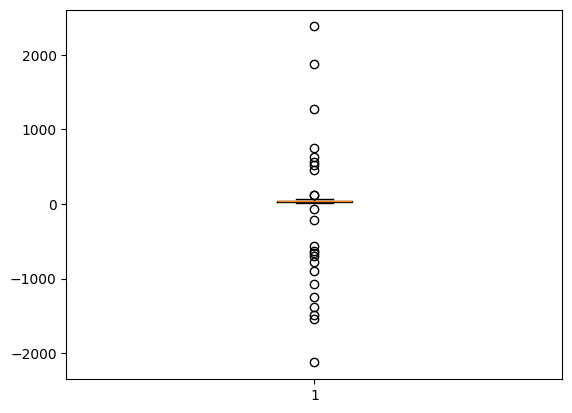

In [ ]:
df_temp = df_clean.dropna(subset=["Age"])
plt.boxplot(df_temp["Age"])

A partir de la inspección visual del boxplot, se identificó la existencia de valores extremos. Se observó que la mayoría de los datos se concentraban en un rango inferior o igual a aproximadamente 60 años, mientras que algunos valores se alejaban considerablemente de esta concentración.

Con base en este comportamiento y en criterios de plausibilidad dentro del contexto laboral, se definió un rango válido de edades entre 0 y 85 años.

###Regla aplicada

Se estableció como criterio que las edades menores o iguales a 0 y mayores o iguales a 85 serían consideradas valores inválidos o atípicos para el análisis.

En lugar de eliminar los registros, estos valores fueron recodificados como datos faltantes (NA), con el fin de conservar las observaciones del dataset:

In [ ]:
outliers = (df_clean["Age"] <= 0) | (df_clean["Age"] >= 85)
print("Porcentaje de outliers:", outliers.mean() * 100)
df_clean.loc[(df_clean["Age"] <= 0) | (df_clean["Age"] >= 85), "Age"] = pd.NA

Porcentaje de outliers: 1.9672131147540985


In [ ]:
df_clean['Age'].isnull().mean()*100

np.float64(6.967213114754098)

Posteriormente, se aplicó una estrategia de imputación para los valores faltantes utilizando la media de la variable:

In [ ]:
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].mean())

Esta decisión se tomó debido a que la proporción de valores faltantes era baja (6.67 %), lo que permite utilizar la media sin generar un sesgo significativo en la distribución y conservar los registros del dataset.

Finalmente, se generó un nuevo boxplot para visualizar el efecto de la limpieza:

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff06fba4170>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff06fba5c10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff0a0d6cbf0>],
 'medians': [<matplotlib.lines.Line2D at 0x7ff06fba6270>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ff06fba65d0>],
 'means': []}

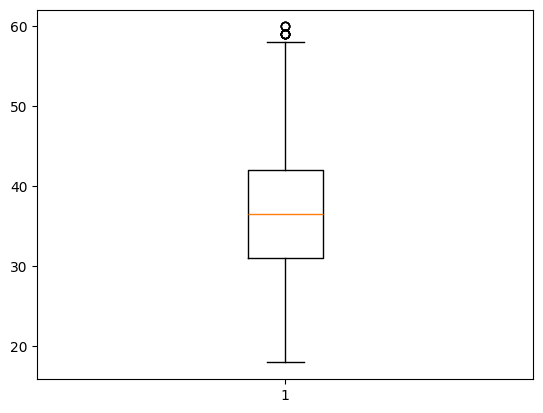

In [ ]:
plt.boxplot(df_clean["Age"])

###Resultado (antes / después)
La tabla de comparación evidencia el proceso de limpieza aplicado a la variable Age. Inicialmente, la variable presentaba valores faltantes y valores atípicos identificados mediante inspección visual. Estos últimos fueron tratados mediante una regla basada en un rango de plausibilidad (0 a 85 años), recodificándolos como valores nulos. Posteriormente, se aplicó imputación con la media para reemplazar los valores faltantes, logrando reducir el porcentaje de NA a 0 %. La diferencia entre la media original y la imputada fue mínima, lo que sugiere que el tratamiento no generó distorsiones significativas en la distribución de la variable. En conjunto, el proceso permitió mejorar la calidad de los datos sin eliminar registros y manteniendo la coherencia de la variable dentro del contexto del análisis.

In [ ]:
pd.set_option('display.max_colwidth', None)
comparacion_Age = pd.DataFrame({
    "Tipo Antes": [df2["Age"].dtype],
    "Tipo Después": [df_clean["Age"].dtype],
    "NA% Antes": [df2["Age"].isna().mean() * 100],
    "NA% Después": [df_clean["Age"].isna().mean() * 100],
    "Outliers": ["Detectados mediante boxplot (1.93%)"],
    "Decisión": ["Recodificación a NA y posterior imputación con la media"]
}, index=["Age"])

comparacion_Age

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
Age,object,float64,1.134089,0.0,Detectados mediante boxplot (1.93%),Recodificación a NA y posterior imputación con la media


##**DistanceFromHome BITA**

###Problema detectado

Durante la exploración de la variable DistanceFromHome se identificaron valores inconsistentes y posibles valores atípicos que podían afectar el análisis. En particular, se observaron distancias negativas, las cuales no tienen sentido dentro del contexto de la variable, así como valores extremos que se alejaban significativamente del comportamiento general de los datos.

###Evidencia

Inicialmente se analizó la distribución de la variable mediante un diagrama de caja (boxplot), lo que permitió identificar la presencia de valores atípicos:

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff06fb2d130>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff06fb2d760>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff06fab4770>],
 'medians': [<matplotlib.lines.Line2D at 0x7ff06fb2dca0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ff06fb2df70>],
 'means': []}

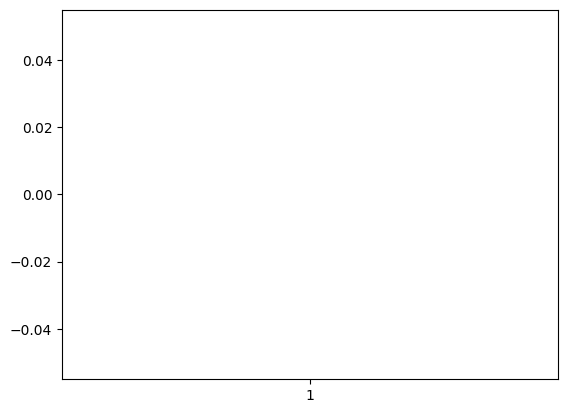

In [ ]:
plt.boxplot(df_clean["DistanceFromHome"])

Posteriormente, se identificaron valores negativos dentro de la variable, los cuales fueron considerados inválidos:

In [ ]:
df_temp = df_clean[df_clean["DistanceFromHome"] >= 0]

Una vez eliminados estos valores, se volvió a visualizar la distribución:

{'whiskers': [<matplotlib.lines.Line2D at 0x7ff06fb63e30>,
 'caps': [<matplotlib.lines.Line2D at 0x7ff06fb64320>,
 'boxes': [<matplotlib.lines.Line2D at 0x7ff06fb63080>],
 'medians': [<matplotlib.lines.Line2D at 0x7ff06fb64950>],
 'fliers': [<matplotlib.lines.Line2D at 0x7ff06fb64c20>],
 'means': []}

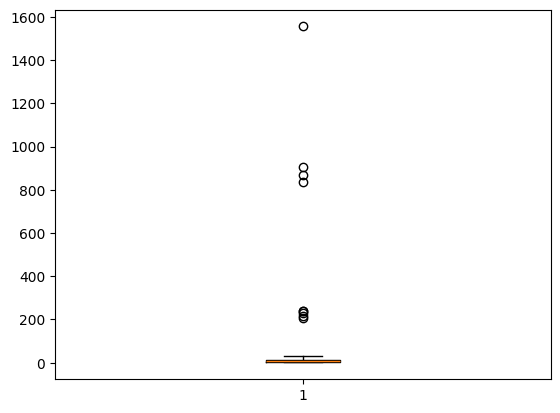

In [ ]:
plt.boxplot(df_temp["DistanceFromHome"])

Para detectar los valores atípicos restantes, se aplicó el método del rango intercuartílico (IQR):

In [ ]:
Q1 = df_clean['DistanceFromHome'].quantile(0.25)
Q3 = df_clean['DistanceFromHome'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

Con estos límites se identificaron los valores fuera del rango esperado.

###Regla aplicada

Se definió como criterio que las distancias negativas y los valores atípicos identificados mediante el método IQR serían considerados inválidos dentro del contexto del análisis.

En lugar de eliminar estos registros, se optó por recodificarlos como valores faltantes (NA), con el fin de cuantificar su impacto y posteriormente tratarlos mediante imputación:

In [ ]:
df_clean.loc[df_clean["DistanceFromHome"] < 0, "DistanceFromHome"] = pd.NA

df_clean.loc[
    (df_clean['DistanceFromHome'] < lower_bound) |
    (df_clean['DistanceFromHome'] > upper_bound),
    'DistanceFromHome'
] = np.nan

Posteriormente, se calculó la media de la variable y se utilizó para imputar los valores faltantes generados:

In [ ]:
mean_value = df_clean['DistanceFromHome'].mean()
df_clean['DistanceFromHome'].fillna(mean_value, inplace=True)

/tmp/ipykernel_586/1745280288.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['DistanceFromHome'].fillna(mean_value, inplace=True)


Esta estrategia permite conservar todos los registros del dataset, evitando la pérdida de información y manteniendo la consistencia de la variable.

###Resultado (antes / después)

Antes del proceso de limpieza, la variable DistanceFromHome presentaba valores inválidos (distancias negativas) y valores atípicos que podían distorsionar el análisis.

Después de aplicar la recodificación de estos valores a NA y su posterior imputación con la media, la variable quedó libre de valores faltantes y con una distribución más estable. Este procedimiento permitió corregir los valores problemáticos sin eliminar registros, manteniendo así la integridad del conjunto de datos.

In [ ]:
pd.set_option('display.max_colwidth', None)
comparacion_Distance = pd.DataFrame({
    "Tipo Antes": [df2["DistanceFromHome"].dtype],
    "Tipo Después": [df_clean["DistanceFromHome"].dtype],
    "NA% Antes": [df2["DistanceFromHome"].isna().mean() * 100],
    "NA% Después": [df_clean["DistanceFromHome"].isna().mean() * 100],
    "Outliers": ["Detectados con método IQR"],
    "Decisión": ["Recodificación de valores inválidos y valores atípicos a NA y posterior imputación"]
}, index=["DistanceFromHome"])

comparacion_Distance

,Tipo Antes,Tipo Después,NA% Antes,NA% Después,Outliers,Decisión
DistanceFromHome,object,float64,7.271514,0.0,Detectados con método IQR,Recodificación de valores inválidos y valores atípicos a NA y posterior imputación


# ⇨ **Parte C - Analisis Exploratorio de Datos**

## ▻ **Medidas de Tendencia Central y Dispersión - Númericas**

In [ ]:
#Variables Numericas

df_numerical = df_clean.select_dtypes(include=['number'])
df_numerical.describe()

,Age,DistanceFromHome
count,1220.000000,1220.000000
mean,37.026432,9.178735
std,8.880171,7.542899
min,18.000000,1.000000
25%,31.000000,3.000000
50%,36.500000,8.000000
75%,42.000000,11.000000
max,60.000000,29.000000


### ⇨ Medidas de tendencia central y dispersión - Age

In [ ]:
media = np.mean(df_numerical["Age"])
mediana = np.median(df_numerical["Age"])
moda = stats.mode(df_numerical["Age"], keepdims=True)

rango = np.max(df_numerical["Age"]) - np.min(df_numerical["Age"])
varianza = np.var(df_numerical["Age"], ddof=1)
desviacion = np.std(df_numerical["Age"], ddof=1)

coef_variacion = (desviacion / media) * 100

print(f"Rango: {rango}")
print("----------------")
print(f"Varianza: {varianza}")
print("----------------")
print(f"Desviación estándar: {desviacion}")
print("----------------")
print(f"Coeficiente de variación (%): {coef_variacion}")
print("----------------")
print(f'Media edad: {media}')
print("----------------")
print(f'Mediana edad: {mediana}')
print("----------------")
print(f'Moda edad: {moda}')


Rango: 42.0
----------------
Varianza: 78.85742990029375
----------------
Desviación estándar: 8.880170600855243
----------------
Coeficiente de variación (%): 23.983328095111716
----------------
Media edad: 37.02643171806168
----------------
Mediana edad: 36.5
----------------
Moda edad: ModeResult(mode=array([37.02643172]), count=array([85]))


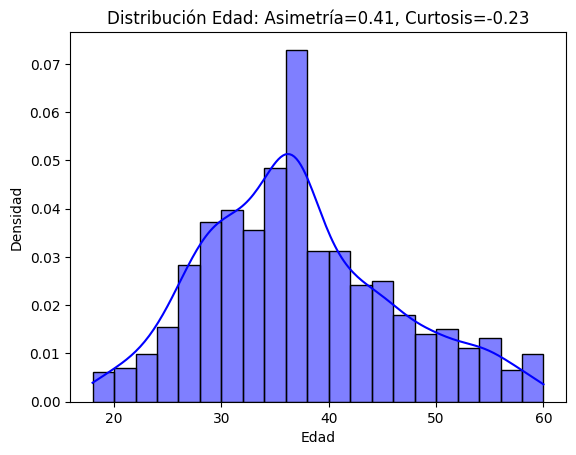

In [ ]:

asimetria = df_clean["Age"].skew()
curtosis = df_clean["Age"].kurt()

sns.histplot(df_clean["Age"], kde=True, color='blue', stat="density")
plt.title(f'Distribución Edad: Asimetría={asimetria:.2f}, Curtosis={curtosis:.2f}')
plt.xlabel("Edad")
plt.ylabel("Densidad")
plt.show()

Interpretación:

* La edad promedio es aproximadamente 37 años
* En este caso como la media es un poco mayor que la mediana, hay inclinación cola derecha
* La edad que más se repite es de 37 años
* En caso de la varianza y la desviación, las edades se desvian 8 años o casi 9 años de la media.
* El coeficiente de variación es menor a un 30% por lo que los datos no son tan altamente variables

### ⇨ Medidas de tendencia central y dispersión - Distance From Home

In [ ]:
media = np.mean(df_numerical["DistanceFromHome"])
mediana = np.median(df_numerical["DistanceFromHome"])
moda = stats.mode(df_numerical["DistanceFromHome"], keepdims=True)

rango = np.max(df_numerical["DistanceFromHome"]) - np.min(df_numerical["DistanceFromHome"])
varianza = np.var(df_numerical["DistanceFromHome"], ddof=1)
desviacion = np.std(df_numerical["DistanceFromHome"], ddof=1)

coef_variacion = (desviacion / media) * 100

print(f"Rango: {rango}")
print("----------------")
print(f"Varianza: {varianza}")
print("----------------")
print(f"Desviación estándar: {desviacion}")
print("----------------")
print(f"Coeficiente de variación (%): {coef_variacion}")
print("----------------")
print(f'Media Distancia desde casa: {media}')
print("----------------")
print(f'Mediana Distancia desde casa: {mediana}')
print("----------------")
print(f'Moda Distancia desde casa: {moda}')


Rango: 28.0
----------------
Varianza: 56.895320846127454
----------------
Desviación estándar: 7.542898703159645
----------------
Coeficiente de variación (%): 82.17797218427818
----------------
Media Distancia desde casa: 9.178735496472509
----------------
Mediana Distancia desde casa: 8.0
----------------
Moda Distancia desde casa: ModeResult(mode=array([2.]), count=array([157]))


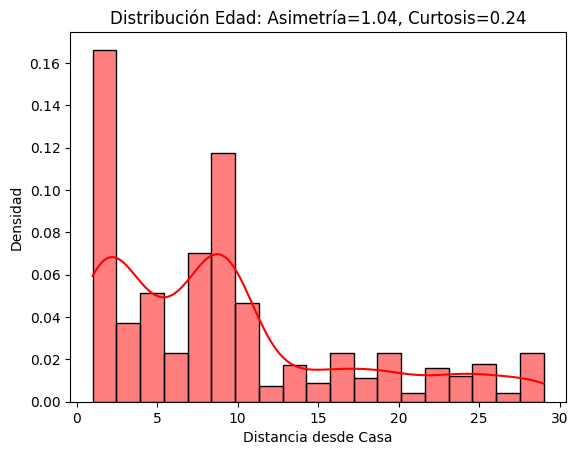

In [ ]:
asimetria = df_clean["DistanceFromHome"].skew()
curtosis = df_clean["DistanceFromHome"].kurt()

sns.histplot(df_clean["DistanceFromHome"], kde=True, color='red', stat="density")
plt.title(f'Distribución Edad: Asimetría={asimetria:.2f}, Curtosis={curtosis:.2f}')
plt.xlabel("Distancia desde Casa")
plt.ylabel("Densidad")
plt.show()

Interpretación:

* En este caso la media es mayor a la mediana por lo tanto existe una asimetría (positiva cola derecha)

* La distancia que más se repite es de 2

* En base a la varianza y la desviación estandar los datos se alejan y están muy dispersos

* En el caso del coeficiente de variación, muy alto y pasa el 80% lo cual significa que los datos son muy dispersos y hay muchos valores extremos.

## ▻ **PRODUCTO C1 - Tablas de Frecuencia y Graficos**

## ⇨ **Datos Cualitativos**

In [ ]:
df_categorical = df_clean.select_dtypes(include=['category'])
df_categorical.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1220 entries, 0 to 1498
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   PerformanceRating  1220 non-null   category
 1   JobSatisfaction    1220 non-null   category
 2   Department         1220 non-null   category
dtypes: category(3)
memory usage: 13.6 KB


###Performance Rating

In [ ]:
df = pd.DataFrame(df_clean, columns=["PerformanceRating"])

frecuencia = df_clean["PerformanceRating"].value_counts().reset_index()
frecuencia.columns = ["PerformanceRating", "Frecuencia"]
frecuencia["Frecuencia relativa"] = frecuencia["Frecuencia"] / len(df_clean)
frecuencia["Porcentaje (%)"] = frecuencia["Frecuencia relativa"] * 100

frecuencia

,PerformanceRating,Frecuencia,Frecuencia relativa,Porcentaje (%)
0,3.0,1025,0.840164,84.016393
1,4.0,195,0.159836,15.983607


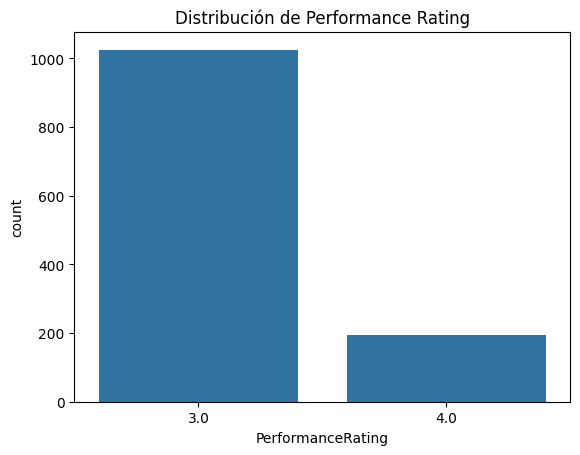

In [ ]:
sns.countplot(x="PerformanceRating", data=df_clean)
plt.title("Distribución de Performance Rating")
plt.show()

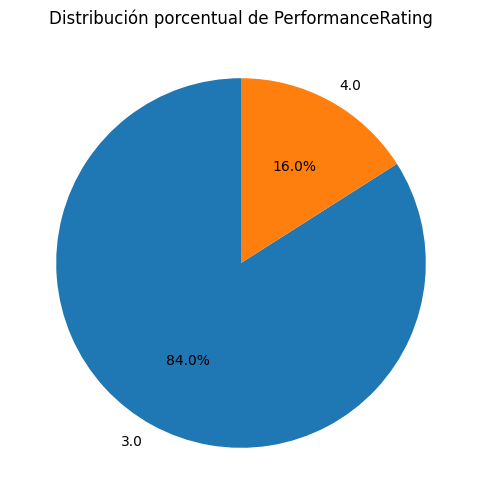

In [ ]:
frecuencia = df["PerformanceRating"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(frecuencia,
        labels=frecuencia.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribución porcentual de PerformanceRating")
plt.show()

Interpretación:

Analizando el grafico de barras y de torta y la frecuencia obtenida de la variable se puede concluir que la mayoria de los empleados cuenta con una calificación de desempeño de 3.0 la cual cuenta más del 80% de frecuencia relativa

### Job Satisfaction

In [ ]:
df = pd.DataFrame(df_clean, columns=["JobSatisfaction"])

frecuencia = df_clean["JobSatisfaction"].value_counts().reset_index()
frecuencia.columns = ["JobSatisfaction", "Frecuencia"]
frecuencia["Frecuencia relativa"] = frecuencia["Frecuencia"] / len(df_clean)
frecuencia["Porcentaje (%)"] = frecuencia["Frecuencia relativa"] * 100

frecuencia

,JobSatisfaction,Frecuencia,Frecuencia relativa,Porcentaje (%)
0,3,377,0.309016,30.901639
1,4,376,0.308197,30.819672
2,1,238,0.195082,19.508197
3,2,229,0.187705,18.770492


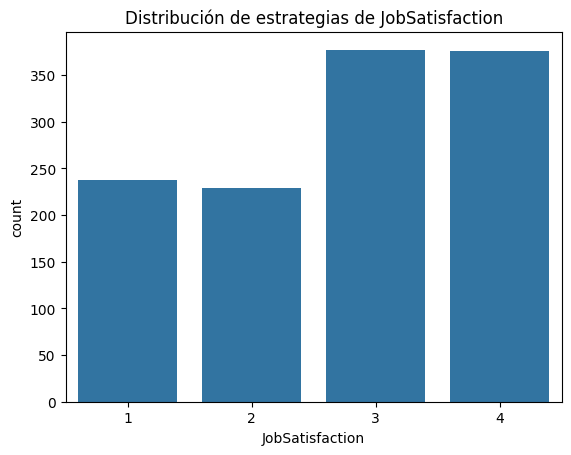

In [ ]:
sns.countplot(x="JobSatisfaction", data=df_clean)
plt.title("Distribución de estrategias de JobSatisfaction")
plt.show()

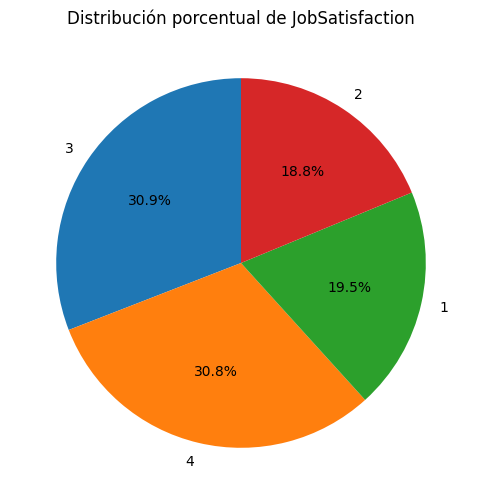

In [ ]:
frecuencia = df_clean["JobSatisfaction"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(frecuencia,
        labels=frecuencia.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribución porcentual de JobSatisfaction")
plt.show()

Interpretación:

En base a los graficos y la tabla de frecuencias podemos concluir que más del 60% de los empleados aproximadamente tienen un nivel de satisfacción de su trabajo de 3 y 4. Ambos niveles tienen casi la misma frecuencia pero en este caso el nivel de satisfacción 3 es el que más tienen los empleados con un 31%

### Department

In [ ]:
df = pd.DataFrame(df_clean, columns=["Department"])

frecuencia = df_clean["Department"].value_counts().reset_index()
frecuencia.columns = ["Department", "Frecuencia"]
frecuencia["Frecuencia relativa"] = frecuencia["Frecuencia"] / len(df_clean)
frecuencia["Porcentaje (%)"] = frecuencia["Frecuencia relativa"] * 100

frecuencia

,Department,Frecuencia,Frecuencia relativa,Porcentaje (%)
0,Research & Development,867,0.710656,71.065574
1,Sales,303,0.248361,24.836066
2,Human Resources,50,0.040984,4.098361


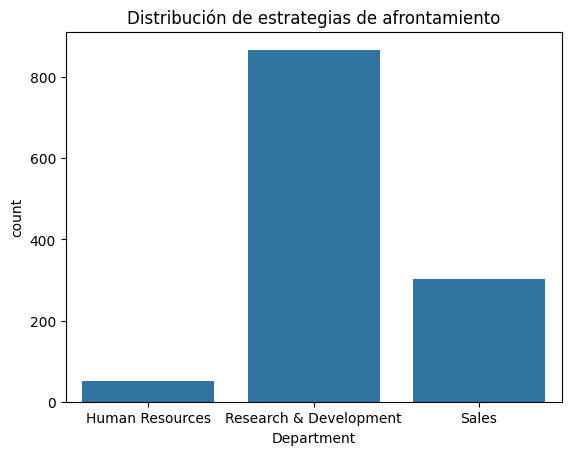

In [ ]:
sns.countplot(x="Department", data=df_clean)
plt.title("Distribución de estrategias de afrontamiento")
plt.show()

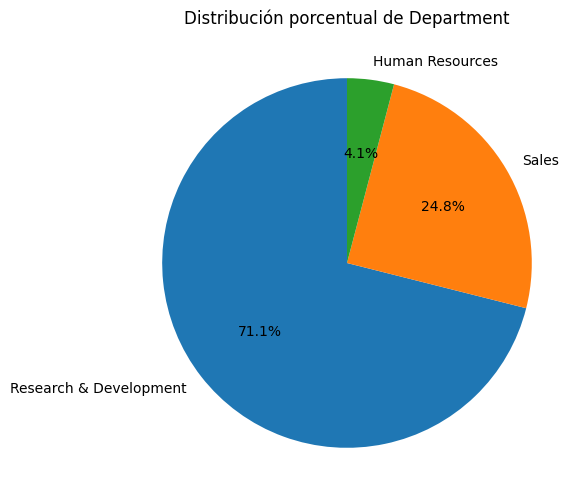

In [ ]:
frecuencia = df_clean["Department"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(frecuencia,
        labels=frecuencia.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribución porcentual de Department")
plt.show()

Interpretación:

Para el caso de esta variable se puede concluir que el departamento en el que trabajan más empleados sería el Research Development con un 70% de frecuencia y menos trabajado es el de Human Resources (Recursos Humanos) con un 4.1%


## ⇨ **Datos Cuantitativos**

###Age

In [ ]:
#Sturges
k = 1 + 3.3*np.log10(len(df_clean["Age"]))
k = round(k)
n = len(df_clean["Age"])
#rango
rango = np.max(df_clean["Age"]) - np.min(df_clean["Age"])

#Amplitud de clase
h = rango / k

#intervalos
intervalos = np.linspace(np.min(df_clean["Age"]), np.max(df_clean["Age"]), k+1)

tabla = pd.cut(df_clean["Age"], bins=intervalos)
frecuencia = pd.value_counts(tabla).sort_index()

tabla_final = pd.DataFrame({
    "Intervalo": frecuencia.index.astype(str),
    "Frecuencia Absoluta": frecuencia.values,
    "Frecuencia Absoluta Acumulada": frecuencia.cumsum(),
    "Frecuencia Relativa": frecuencia.values / n,
    "Frecuencia Relativa Acumulada": frecuencia.cumsum() / n
})

tabla_final

/tmp/ipykernel_586/16850052.py:15: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frecuencia = pd.value_counts(tabla).sort_index()


,Intervalo,Frecuencia Absoluta,Frecuencia Absoluta Acumulada,Frecuencia Relativa,Frecuencia Relativa Acumulada
Age,,,,,
"(18.0, 21.818]","(18.0, 21.818]",25,25,0.020492,0.020492
"(21.818, 25.636]","(21.818, 25.636]",62,87,0.050820,0.071311
"(25.636, 29.455]","(25.636, 29.455]",160,247,0.131148,0.202459
"(29.455, 33.273]","(29.455, 33.273]",184,431,0.150820,0.353279
"(33.273, 37.091]","(33.273, 37.091]",296,727,0.242623,0.595902
"(37.091, 40.909]","(37.091, 40.909]",116,843,0.095082,0.690984
"(40.909, 44.727]","(40.909, 44.727]",122,965,0.100000,0.790984
"(44.727, 48.545]","(44.727, 48.545]",95,1060,0.077869,0.868852
"(48.545, 52.364]","(48.545, 52.364]",66,1126,0.054098,0.922951


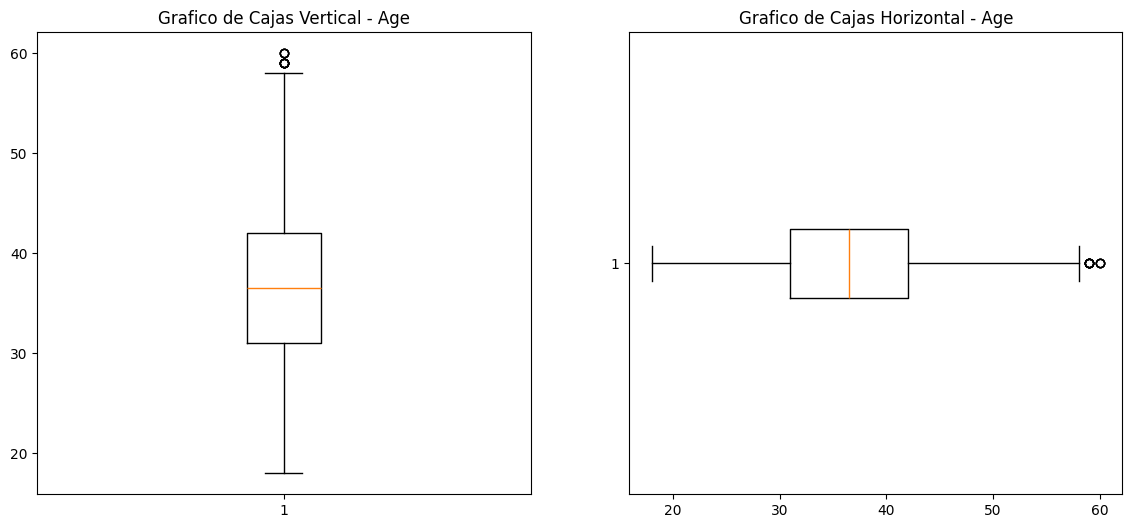

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df_clean["Age"])
plt.title('Grafico de Cajas Vertical - Age')


plt.subplot(1, 2, 2)
plt.boxplot(df_clean["Age"], vert=False)
plt.title('Grafico de Cajas Horizontal - Age')
plt.show()

En este caso, se presentan pocos valores atipicos (outliers) y la mediana se encuentra entre los 30 y 40 años.

(array([ 43.,  79., 179., 195., 284., 165., 105.,  71.,  59.,  40.]),
 array([18. , 22.2, 26.4, 30.6, 34.8, 39. , 43.2, 47.4, 51.6, 55.8, 60. ]),
 <BarContainer object of 10 artists>)

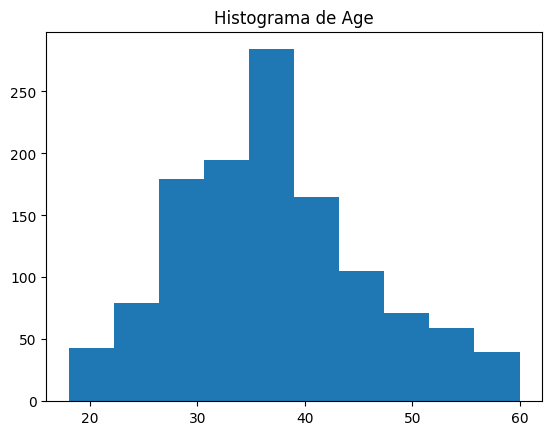

In [ ]:
plt.title("Histograma de Age")
plt.hist(df_clean["Age"], bins=10)

El histograma revela que la fuerza laboral se concentra principalmente en la adultez joven, específicamente entre los 30 y 40 años, con un pico máximo de frecuencia en el intervalo de 35 y casi 40 años, mientras que la participación disminuye significativamente hacia los extremos de la juventud temprana y la edad cercana a la jubilación.

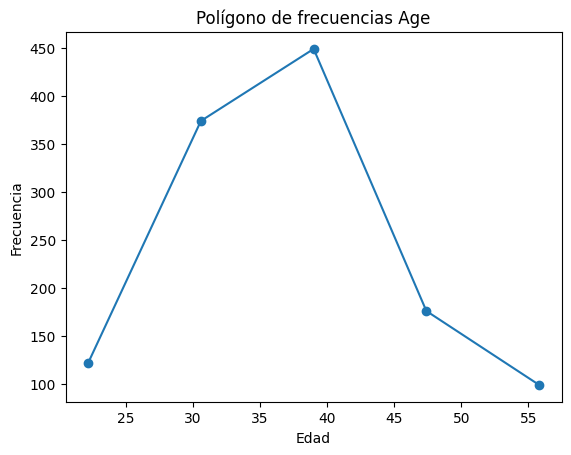

In [ ]:
frecuencia, intervalos = np.histogram(df_clean["Age"], bins=5)
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2

plt.plot(puntos_medios, frecuencia, marker='o')
plt.title("Polígono de frecuencias Age")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

El polígono de frecuencias confirma que el punto de maximo se alcanza a los 39 años, para luego iniciar un descenso constante conforme aumenta la edad. Se observa una alta densidad poblacional que se sostiene entre los 30 y 40 años, lo que valida la predominancia de adultos jóvenes. Por el contrario, los extremos de la gráfica muestran una participación reducida, especialmente al acercarse a los 60 años, donde la frecuencia cae a su punto mínimo.

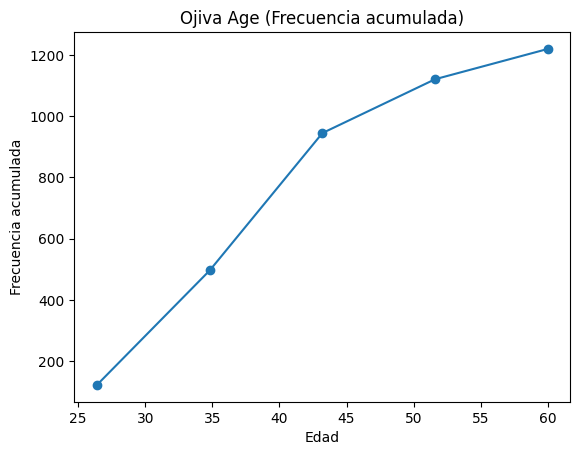

In [ ]:
frecuencia, intervalos = np.histogram(df_clean["Age"], bins=5)
frecuencia_acum = np.cumsum(frecuencia)

plt.plot(intervalos[1:], frecuencia_acum, marker='o')
plt.title("Ojiva Age (Frecuencia acumulada)")
plt.xlabel("Edad")
plt.ylabel("Frecuencia acumulada")
plt.show()

La ojiva demuestra un crecimiento acelerado de la población hasta los 43 o 44 años que es la linea más empinada.

###Distance From Home

In [ ]:
#Sturges
k = 1 + 3.3*np.log10(len(df_clean["DistanceFromHome"]))
k = round(k)
n = len(df_clean["DistanceFromHome"])
#rango
rango = np.max(df_clean["DistanceFromHome"]) - np.min(df_clean["DistanceFromHome"])

#Amplitud de clase
h = rango / k

#intervalos
intervalos = np.linspace(np.min(df_clean["DistanceFromHome"]), np.max(df_clean["DistanceFromHome"]), k+1)

tabla = pd.cut(df_clean["DistanceFromHome"], bins=intervalos)
frecuencia = pd.value_counts(tabla).sort_index()

tabla_final = pd.DataFrame({
    "Intervalo": frecuencia.index.astype(str),
    "Frecuencia Absoluta": frecuencia.values,
    "Frecuencia Absoluta Acumulada": frecuencia.cumsum(),
    "Frecuencia Relativa": frecuencia.values / n,
    "Frecuencia Relativa Acumulada": frecuencia.cumsum() / n
})

tabla_final

/tmp/ipykernel_586/627819867.py:15: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  frecuencia = pd.value_counts(tabla).sort_index()


,Intervalo,Frecuencia Absoluta,Frecuencia Absoluta Acumulada,Frecuencia Relativa,Frecuencia Relativa Acumulada
DistanceFromHome,,,,,
"(1.0, 3.545]","(1.0, 3.545]",224,224,0.183607,0.183607
"(3.545, 6.091]","(3.545, 6.091]",133,357,0.109016,0.292623
"(6.091, 8.636]","(6.091, 8.636]",126,483,0.103279,0.395902
"(8.636, 11.182]","(8.636, 11.182]",295,778,0.241803,0.637705
"(11.182, 13.727]","(11.182, 13.727]",28,806,0.022951,0.660656
"(13.727, 16.273]","(13.727, 16.273]",58,864,0.047541,0.708197
"(16.273, 18.818]","(16.273, 18.818]",35,899,0.028689,0.736885
"(18.818, 21.364]","(18.818, 21.364]",48,947,0.039344,0.776230
"(21.364, 23.909]","(21.364, 23.909]",29,976,0.023770,0.800000


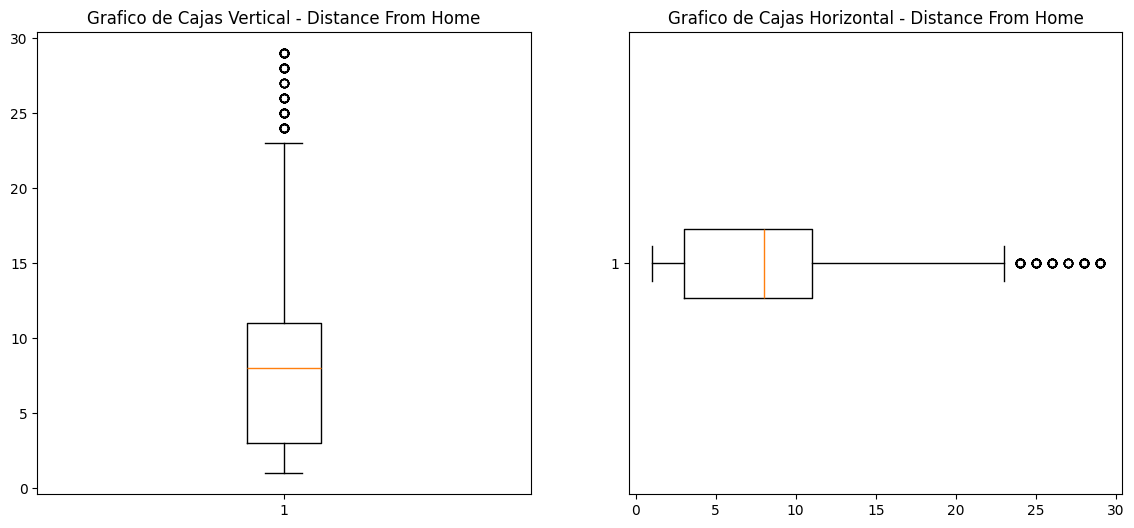

In [ ]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.boxplot(df_clean["DistanceFromHome"])
plt.title('Grafico de Cajas Vertical - Distance From Home')


plt.subplot(1, 2, 2)
plt.boxplot(df_clean["DistanceFromHome"], vert=False)
plt.title('Grafico de Cajas Horizontal - Distance From Home')
plt.show()

Los datos se concentran en una mediana cercana a 8, con una distribución sesgada hacia la derecha.
Existen múltiples valores atípicos representados por los puntos superiores, indicando casos aislados con distancias significativamente mayores a 24.

(array([366., 133., 337.,  97.,  31.,  57.,  61.,  36.,  54.,  48.]),
 array([ 1. ,  3.8,  6.6,  9.4, 12.2, 15. , 17.8, 20.6, 23.4, 26.2, 29. ]),
 <BarContainer object of 10 artists>)

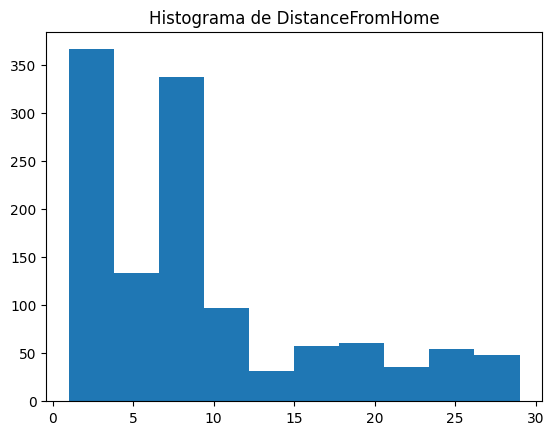

In [ ]:
plt.title("Histograma de DistanceFromHome")
plt.hist(df_clean["DistanceFromHome"], bins=10)

La mayoría de los datos se agrupan en distancias cortas menores a 10, mostrando dos picos al inicio, entre 0 y 10

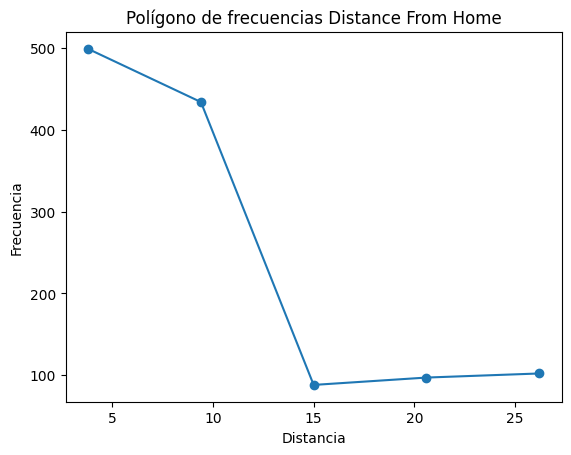

In [ ]:
frecuencia, intervalos = np.histogram(df_clean["DistanceFromHome"], bins=5)
puntos_medios = (intervalos[:-1] + intervalos[1:]) / 2

plt.plot(puntos_medios, frecuencia, marker='o')
plt.title("Polígono de frecuencias Distance From Home")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia")
plt.show()

Se observa una caída drástica de la frecuencia después de los 10 km, pasando de niveles superiores a 400 hasta menos de 100. Hay más población a distancias cortas

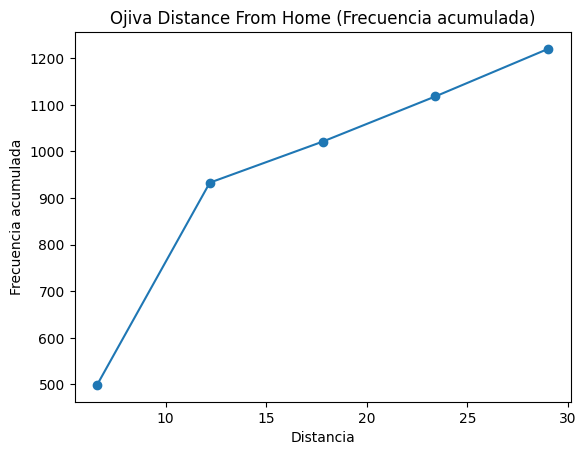

In [ ]:
frecuencia, intervalos = np.histogram(df_clean["DistanceFromHome"], bins=5)
frecuencia_acum = np.cumsum(frecuencia)

plt.plot(intervalos[1:], frecuencia_acum, marker='o')
plt.title("Ojiva Distance From Home (Frecuencia acumulada)")
plt.xlabel("Distancia")
plt.ylabel("Frecuencia acumulada")
plt.show()

Hay un crecimiento hasta casi 12 km

## ▻ **Correlación entre Númericas**

In [ ]:
pearson = df_clean["Age"].corr(df_clean["DistanceFromHome"], method="pearson")
print(f"Pearson : {pearson}")
spearman = df_clean["Age"].corr(df_clean["DistanceFromHome"], method="spearman")
print(f"Spearman : {spearman}")


Pearson : 0.010933694599309065
Spearman : -0.011494174449884435


Ambos coeficientes son extremadamente cercanos a cero, lo que indica que no existe una relación lineal ni monótona entre la edad y la distancia al hogar. Las dos variables no se relacionan como tal y no sirven para predecir la una de la otra.

## **PRODUCTO C2 - INTERPRETACIÓN GENERAL ESCRITA DEL ANALISIS EXPLORATORIO Y GRAFICAS**

El análisis de la variable **edad (AGE)** muestra que la mayor parte de la población se concentra entre los 30 y 40 años, con un pico cercano a los 39, lo que indica predominio de adultos jóvenes. A partir de este punto, la frecuencia disminuye progresivamente, siendo menor en edades mayores. La ojiva confirma un crecimiento acumulado rápido hasta aproximadamente los 43 o 44 años.

En cuanto a la **distancia al hogar**, los datos se concentran en valores bajos, con una mediana cercana a 8 km. La mayoría de las personas vive a menos de 10 km, y después de este punto la frecuencia cae notablemente. Se identifican varios valores atípicos que representan distancias considerablemente mayores, generando una distribución sesgada hacia la derecha. La ojiva muestra un crecimiento acumulado hasta cerca de los 12 km.

Respecto a la relación entre ambas variables, los coeficientes de correlación de Pearson y Spearman son cercanos a cero, lo que indica que no existe relación significativa entre la edad y la distancia al hogar, comportándose como variables independientes. **Esto significa que la edad de una persona no permite predecir qué tan lejos vive; son variables independientes en este conjunto de datos.**

En general se observa en las variables una ligera distribución con cola a la derecha, evidenciada porque la media es mayor que la mediana, aunque sea por una pequeña diferencia, lo que indica la presencia de valores altos que influyen en la distribución.



# ⇨ **CONCLUSIONES Y LIMITACIONES**

* Se logró estandarizar correctamente los tipos de datos, garantizando coherencia para el análisis.

* Se lograron aplicar reglas apropiadas para la limpieza de datos.


* El tratamiento de valores faltantes redujo el porcentaje de NA y fortaleció la calidad de los datos.

* La comparación antes vs después evidenció una mejora clara en confiabilidad.

* Se identificaron outliers, especialmente en distancia, que explican la asimetría a la derecha.

* Se conservaron algunos outliers relevantes para no perder información importante.


* No se encontró relación significativa entre las variables númericas (correlación cercana a cero).

**IMPORTANCIA DEL PROCESO:**

* Mejora la calidad y confiabilidad de los datos.

* Reduce errores en el análisis y en la toma de decisiones.

* Asegura consistencia en el manejo de datos faltantes y atípicos.

**LIMITACIONES:**

* El análisis se basa en pocas variables, limitando una visión más completa.

* La imputación o eliminación de datos puede introducir sesgos

* Es un análisis descriptivo, por lo que no permite inferir causalidad ni generalizar ampliamente.

